In [2]:
import sys
from pathlib import Path
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

def find_project_root(start=None):
    if start is None:
        start = Path.cwd().resolve()

    for p in [start] + list(start.parents):
        if (p / "data").exists():
            return p

    return start


PROJECT_ROOT = find_project_root()
sys.path.append(str(PROJECT_ROOT))

import settings as S


srs_v1_bdn_sav
shape: (43805, 10)
total samples: 43805
outliers: 1483
ratio: 0.033854582810181486
number of runs: 337
mean run length: 4.400593471810089
median run length: 3.0
min run length: 1
max run length: 28

Cumulative run length distribution:
runs ≤ 1: 2.4%
runs ≤ 2: 14.5%
runs ≤ 3: 63.2%
runs ≤ 4: 71.2%
runs ≤ 5: 76.0%
runs ≤ 6: 79.5%
runs ≤ 7: 84.6%
runs ≤ 8: 90.2%
runs ≤ 9: 93.2%


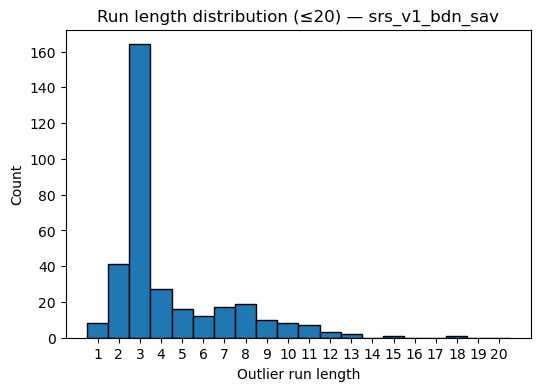


srs_v1_drn_sav
shape: (43114, 10)
total samples: 43114
outliers: 1379
ratio: 0.03198497007932458
number of runs: 392
mean run length: 3.517857142857143
median run length: 3.0
min run length: 1
max run length: 12

Cumulative run length distribution:
runs ≤ 1: 0.3%
runs ≤ 2: 4.1%
runs ≤ 3: 80.1%
runs ≤ 4: 84.2%
runs ≤ 5: 89.5%
runs ≤ 6: 96.2%
runs ≤ 7: 98.0%
runs ≤ 8: 98.0%
runs ≤ 9: 98.7%


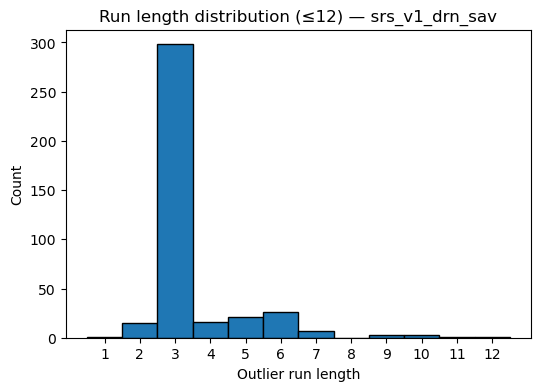


srs_v1_psn_sav
shape: (35133, 10)
total samples: 35133
outliers: 1087
ratio: 0.03093957248171235
number of runs: 306
mean run length: 3.552287581699346
median run length: 3.0
min run length: 1
max run length: 11

Cumulative run length distribution:
runs ≤ 1: 1.0%
runs ≤ 2: 11.8%
runs ≤ 3: 78.1%
runs ≤ 4: 83.7%
runs ≤ 5: 88.6%
runs ≤ 6: 93.5%
runs ≤ 7: 94.8%
runs ≤ 8: 96.1%
runs ≤ 9: 98.4%


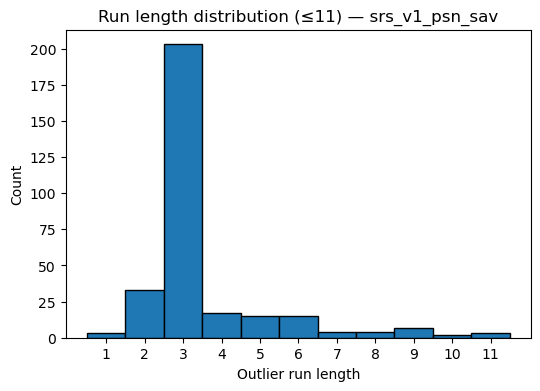


srs_v1_rkm_sav
shape: (47629, 10)
total samples: 47629
outliers: 1568
ratio: 0.03292111948602742
number of runs: 432
mean run length: 3.6296296296296298
median run length: 3.0
min run length: 1
max run length: 12

Cumulative run length distribution:
runs ≤ 1: 0.5%
runs ≤ 2: 8.1%
runs ≤ 3: 77.1%
runs ≤ 4: 83.8%
runs ≤ 5: 87.5%
runs ≤ 6: 91.4%
runs ≤ 7: 94.4%
runs ≤ 8: 96.3%
runs ≤ 9: 98.8%


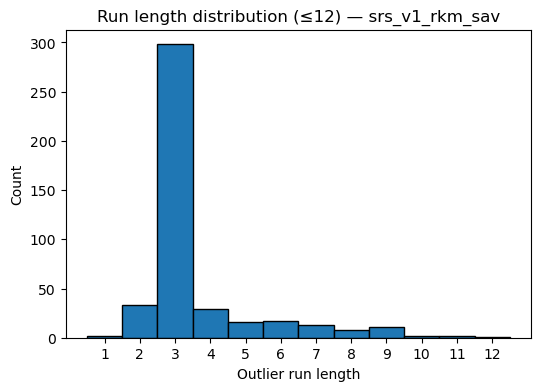


srs_v1_svd_sav
shape: (44810, 10)
total samples: 44810
outliers: 747
ratio: 0.016670386074536934
number of runs: 231
mean run length: 3.2337662337662336
median run length: 3.0
min run length: 2
max run length: 11

Cumulative run length distribution:
runs ≤ 1: 0.0%
runs ≤ 2: 8.2%
runs ≤ 3: 87.0%
runs ≤ 4: 91.3%
runs ≤ 5: 94.8%
runs ≤ 6: 98.7%
runs ≤ 7: 98.7%
runs ≤ 8: 99.1%
runs ≤ 9: 99.1%


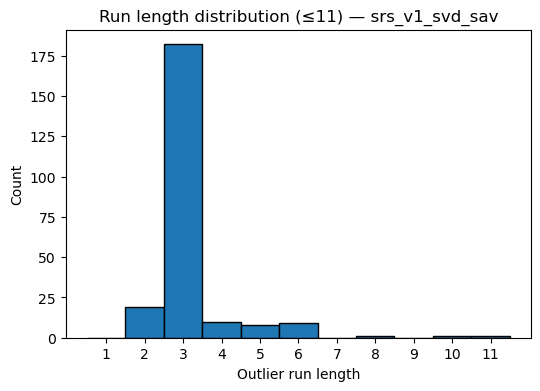

recording_id,n_total,n_outliers,outlier_ratio,n_runs,mean_run_len,median_run_len,min_run_len,max_run_len
str,i64,i64,f64,i64,f64,f64,i64,i64
"""srs_v1_bdn_sav""",43805,1483,0.033855,337,4.400593,3.0,1,28
"""srs_v1_drn_sav""",43114,1379,0.031985,392,3.517857,3.0,1,12
"""srs_v1_psn_sav""",35133,1087,0.03094,306,3.552288,3.0,1,11
"""srs_v1_rkm_sav""",47629,1568,0.032921,432,3.62963,3.0,1,12
"""srs_v1_svd_sav""",44810,747,0.01667,231,3.233766,3.0,2,11


In [3]:
recordings = S.SARASUDA_VARNAM

summary_rows = []

for recording_id in recordings:

    print(f"\n==============================")
    print(f"{recording_id}")
    print(f"==============================")

    debug_path = (
        S.DATA_INTERIM
        / recording_id
        / "pitch"
        / f"{recording_id}_pitch_preprocessed_debug.parquet"
    )

    df = pl.read_parquet(debug_path)

    # ---------------------------------------------------
    # Basic statistics
    # ---------------------------------------------------

    n_total = df.height
    n_outliers = df.filter(pl.col("is_outlier")).height
    ratio = n_outliers / n_total if n_total > 0 else np.nan

    mask = df["is_outlier"].to_numpy()

    # ---------------------------------------------------
    # Compute outlier runs
    # ---------------------------------------------------

    runs = []
    current = 0

    for v in mask:
        if v:
            current += 1
        else:
            if current > 0:
                runs.append(current)
            current = 0

    if current > 0:
        runs.append(current)

    runs = np.array(runs, dtype=int)

    n_runs = len(runs)

    if n_runs > 0:
        mean_len = runs.mean()
        median_len = np.median(runs)
        max_len = runs.max()
        min_len = runs.min()
    else:
        mean_len = 0
        median_len = 0
        max_len = 0
        min_len = 0

    # ---------------------------------------------------
    # Print summary
    # ---------------------------------------------------

    print("shape:", df.shape)
    print("total samples:", n_total)
    print("outliers:", n_outliers)
    print("ratio:", ratio)
    print("number of runs:", n_runs)
    print("mean run length:", mean_len)
    print("median run length:", median_len)
    print("min run length:", min_len)
    print("max run length:", max_len)

    # ---------------------------------------------------
    # Cumulative run length distribution
    # ---------------------------------------------------

    if n_runs > 0:

        print("\nCumulative run length distribution:")

        for k in range(1, 10):
            pct = np.mean(runs <= k) * 100
            print(f"runs ≤ {k}: {pct:.1f}%")

        # ---------------------------------------------------
        # Histogram
        # ---------------------------------------------------

        max_plot_len = min(max_len, 20)

        plt.figure(figsize=(6,4))

        plt.hist(
            runs[runs <= max_plot_len],
            bins=np.arange(0.5, max_plot_len + 1.5, 1),
            edgecolor="black"
        )

        plt.xticks(range(1, max_plot_len + 1))

        plt.xlabel("Outlier run length")
        plt.ylabel("Count")
        plt.title(f"Run length distribution (≤{max_plot_len}) — {recording_id}")

        plt.show()

    else:
        print("\nNo outlier runs")

    # ---------------------------------------------------
    # Store results
    # ---------------------------------------------------

    summary_rows.append({
        "recording_id": recording_id,
        "n_total": n_total,
        "n_outliers": n_outliers,
        "outlier_ratio": ratio,
        "n_runs": n_runs,
        "mean_run_len": mean_len,
        "median_run_len": median_len,
        "min_run_len": min_len,
        "max_run_len": max_len,
    })


summary_df = pl.DataFrame(summary_rows)
summary_df

In [ ]:
recordings = S.SARASUDA_VARNAM

summary_rows = []

for recording_id in recordings:

    print(f"\n==============================")
    print(f"{recording_id}")
    print(f"==============================")

    debug_path = (
        S.DATA_INTERIM
        / recording_id
        / "pitch"
        / f"{recording_id}_pitch_preprocessed_debug.parquet"
    )

    df = pl.read_parquet(debug_path)

    # ---------------------------------------------------
    # Basic statistics
    # ---------------------------------------------------

    n_total = df.height
    n_outliers = df.filter(pl.col("is_outlier")).height
    ratio = n_outliers / n_total if n_total > 0 else np.nan

    mask = df["is_outlier"].to_numpy()

    # ---------------------------------------------------
    # Compute outlier runs
    # ---------------------------------------------------

    runs = []
    current = 0

    for v in mask:
        if v:
            current += 1
        else:
            if current > 0:
                runs.append(current)
            current = 0

    if current > 0:
        runs.append(current)

    runs = np.array(runs, dtype=int)

    n_runs = len(runs)

    if n_runs > 0:
        mean_len = runs.mean()
        median_len = np.median(runs)
        max_len = runs.max()
        min_len = runs.min()
    else:
        mean_len = 0
        median_len = 0
        max_len = 0
        min_len = 0

    # ---------------------------------------------------
    # Print summary
    # ---------------------------------------------------

    print("shape:", df.shape)
    print("total samples:", n_total)
    print("outliers:", n_outliers)
    print("ratio:", ratio)
    print("number of runs:", n_runs)
    print("mean run length:", mean_len)
    print("median run length:", median_len)
    print("min run length:", min_len)
    print("max run length:", max_len)

    # ---------------------------------------------------
    # Cumulative run length distribution
    # ---------------------------------------------------

    if n_runs > 0:

        print("\nCumulative run length distribution:")

        for k in range(1, 10):
            pct = np.mean(runs <= k) * 100
            print(f"runs ≤ {k}: {pct:.1f}%")

        # ---------------------------------------------------
        # Histogram
        # ---------------------------------------------------

        max_plot_len = min(max_len, 20)

        plt.figure(figsize=(6,4))

        plt.hist(
            runs[runs <= max_plot_len],
            bins=np.arange(0.5, max_plot_len + 1.5, 1),
            edgecolor="black"
        )

        plt.xticks(range(1, max_plot_len + 1))

        plt.xlabel("Outlier run length")
        plt.ylabel("Count")
        plt.title(f"Run length distribution (≤{max_plot_len}) — {recording_id}")

        plt.show()

    else:
        print("\nNo outlier runs")

    # ---------------------------------------------------
    # Store results
    # ---------------------------------------------------

    summary_rows.append({
        "recording_id": recording_id,
        "n_total": n_total,
        "n_outliers": n_outliers,
        "outlier_ratio": ratio,
        "n_runs": n_runs,
        "mean_run_len": mean_len,
        "median_run_len": median_len,
        "min_run_len": min_len,
        "max_run_len": max_len,
    })


summary_df = pl.DataFrame(summary_rows)
summary_df